<a href="https://colab.research.google.com/github/APES-M-JeissonS-JuanB/Sesion_4_Regresion_lineal_simple_y_Analisis_de_varianza/blob/main/Sanchez_Jeisson_y_Bogota_Juan_CasoEstudio_sesion4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller de Regresión Lineal Simple

## Jeisson David Sanchez Gomez y Juan Daniel Bogotá Fuentes

---

## Punto 1: Introducción a la Regresión Lineal Simple

En este punto vamos a:
1. Genere un conjunto de datos aleatorios que contenga 20 puntos.
2. Utilice la biblioteca `scikit-learn` para ajustar un modelo de regresión lineal simple.
3. Grafique los puntos y la línea de regresión.

In [54]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### 1.1 Generación del conjunto de datos aleatorios

In [55]:
# Generar datos simulados
np.random.seed(0)
X = 2 * np.random.rand(20, 1) * 10
y = 5 + 3 * X + np.random.randn(20, 1) * 5

print("Valores de X:")
print(X.ravel())
print("\nValores de y:")
print(y.ravel())

Valores de X:
[10.97627008 14.30378733 12.05526752 10.89766366  8.47309599 12.91788226
  8.75174423 17.83546002 19.27325521  7.66883038 15.83450076 10.5778984
 11.36089122 18.51193277  1.42072116  1.74258599  0.40436795 16.65239691
 15.56313502 17.40024296]

Valores de y:
[45.3992056  46.88557066 42.73114107 33.42251228 17.65433888 47.02173976
 35.57741367 54.79555494 74.16853875 20.73466276 52.73229487 35.79777594
 46.74656974 67.88259215 10.03690062 12.11857058  1.77417511 45.05320839
 49.94984431 57.98247374]


### 1.2 Ajuste del modelo de regresión lineal simple con scikit-learn

In [56]:
modelo_p1 = LinearRegression()
# Entrenamos el modelo
modelo_p1.fit(X, y)
# Obtenemos los parámetros estimados
intercepto = modelo_p1.intercept_[0]
pendiente = modelo_p1.coef_[0][0]

print(f"Intercepto (a): {intercepto:.4f}")
print(f"Pendiente (b): {pendiente:.4f}")
print(f"Ecuación de la recta ajustada: y = {intercepto:.4f} + {pendiente:.4f} * X")

Intercepto (a): 2.3115
Pendiente (b): 3.2337
Ecuación de la recta ajustada: y = 2.3115 + 3.2337 * X


### 1.3 Gráfico de los puntos y la línea de regresión

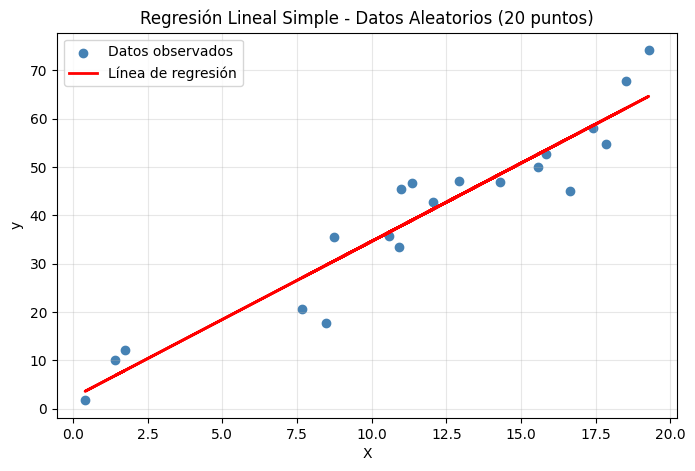

In [57]:
y_pred_p1 = modelo_p1.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', label='Datos observados')
plt.plot(X, y_pred_p1, color='red', linewidth=2, label='Línea de regresión')
plt.title('Regresión Lineal Simple - Datos Aleatorios (20 puntos)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Punto 2: Análisis de Residuos

En este punto vamos a:
1. Utilice el conjunto de datos de iris disponible en la biblioteca `seaborn`.
2. Realice una regresión lineal simple para predecir el ancho del pétalo basado en su longitud.
3. Calcule los residuos y grafique un histograma para analizar su distribución.

In [58]:
# Importar librerías necesarias
import seaborn as sns
import pandas as pd

### 2.1 Carga del conjunto de datos iris

In [59]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2.2 Regresión lineal simple: longitud del pétalo vs. ancho del pétalo

In [60]:
# Variable independiente: longitud del pétalo
X_iris = iris[['petal_length']]

# Variable dependiente: ancho del pétalo
y_iris = iris['petal_width']

# Crear el modelo de regresión lineal
modelo_p2 = LinearRegression()
# Entrenar el modelo
modelo_p2.fit(X_iris, y_iris)

# Parámetros estimados
print(f"Intercepto: {modelo_p2.intercept_:.4f}")
print(f"Pendiente: {modelo_p2.coef_[0]:.4f}")

# Predicciones del modelo
y_pred_iris = modelo_p2.predict(X_iris)

Intercepto: -0.3631
Pendiente: 0.4158


### 2.3 Cálculo de los residuos

In [61]:
residuos_iris = y_iris - y_pred_iris

print("Estadísticas descriptivas de los residuos:")
print(residuos_iris.describe())

Estadísticas descriptivas de los residuos:
count    1.500000e+02
mean    -1.006602e-16
std      2.057903e-01
min     -5.651548e-01
25%     -1.235793e-01
50%     -1.898206e-02
75%      1.328758e-01
max      6.427229e-01
Name: petal_width, dtype: float64


### 2.4 Histograma de los residuos

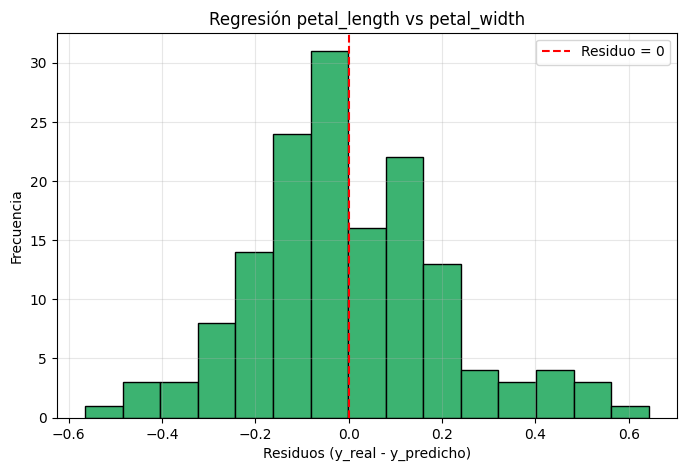

In [62]:
plt.figure(figsize=(8, 5))
plt.hist(residuos_iris, bins=15, color='mediumseagreen', edgecolor='black')
plt.title('Regresión petal_length vs petal_width')
plt.xlabel('Residuos (y_real - y_predicho)')
plt.ylabel('Frecuencia')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Residuo = 0')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpretación:** El histograma se ve bastante simétrico y centrado en cero, con la mayoría de los residuos entre -0.2 y 0.2. Esto nos dice que el modelo no se está equivocando sistemáticamente para arriba o para abajo, sino que el error es más o menos parejo. O sea, el supuesto de normalidad se cumple razonablemente bien, aunque no es perfecto (hay algunos residuos que se van hasta 0.6).

## Punto 3: Intervalos de Confianza

En este punto vamos a:
1. Generar otro conjunto de datos aleatorios que contenga 50 puntos.
2. Utilizar `statsmodels` para ajustar un modelo de regresión lineal simple.
3. Calcular e interpretar los intervalos de confianza para los parámetros del modelo.

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

### 3.1 Generación del conjunto de datos aleatorios (50 puntos)

In [64]:
# Generar datos simulados
np.random.seed(42)
X_p3 = 2 * np.random.rand(50, 1) * 10
y_p3 = 5 + 3 * X_p3 + np.random.randn(50, 1) * 5

print("Valores de X:")
print(X_p3.ravel())
print("\nValores de y:")
print(y_p3.ravel())

Valores de X:
[ 7.49080238 19.01428613 14.63987884 11.97316968  3.12037281  3.11989041
  1.16167224 17.32352292 12.02230023 14.16145156  0.41168989 19.39819704
 16.64885282  4.24678221  3.63649934  3.6680902   6.08484486 10.49512863
  8.63890037  5.8245828  12.23705789  2.78987721  5.84289297  7.32723687
  9.12139968 15.70351923  3.99347564 10.28468877 11.84829138  0.92900825
 12.15089704  3.41048247  1.30103186 18.97771075 19.31264066 16.16794696
  6.09227538  1.95344228 13.68466053  8.80304987  2.4407647   9.9035382
  0.68777042 18.18640804  5.17559963 13.25044569  6.23422152 10.40136042
 10.93420559  3.69708911]

Valores de y:
[31.16474003 62.89969979 48.3413951  39.41399057  6.96850847 10.76045018
  6.18182288 62.25617988 42.78499215 38.66915389  7.8554895  61.26917973
 51.56194845 20.79872808 21.06449564 20.66067119 19.05844696 34.93932402
 32.57301828 27.35147405 39.31530249 12.44133676 16.99700404 21.00067748
 36.42682816 58.89175783 16.62037632 40.87173079 42.35305426  4.561425

### 3.2 Ajuste del modelo con statsmodels

A diferencia de `scikit-learn`, `statsmodels` por defecto ajusta una recta que pasa por el origen. Para incluir el intercepto, es necesario agregar una constante a la variable independiente con `sm.add_constant()`.

In [65]:
X_p3_sm = sm.add_constant(X_p3)

modelo_p3 = sm.OLS(y_p3, X_p3_sm).fit()

modelo_p3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     661.5
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           1.00e-29
Time:                        03:37:31   Log-Likelihood:                -146.55
No. Observations:                  50   AIC:                             297.1
Df Residuals:                      48   BIC:                             300.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4834      1.213      4.521      0.000       3.045       7.922
x1             2.9441      0.114     25.719      0.000       2.714       3.174
==============================================================================
Omnibus:                        2.171   Durbin-Watson:                   2.127
Prob(Omnibus):                  0.338   Jarque-Bera (JB):                1.664
Skew:                          -0.447   Prob(JB):                        0.435
Kurtosis:                       3.036   Cond. No.                         19.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 3.3 Intervalos de confianza para los parámetros

El método `.conf_int()` calcula los intervalos de confianza (por defecto al 95%) para el intercepto y la pendiente del modelo.

In [66]:
# Intervalos de confianza al 95% (alpha = 0.05)
import pandas as pd

intervalos_p3 = pd.DataFrame(
    modelo_p3.conf_int(alpha=0.05),
    columns=['Límite inferior (2.5%)', 'Límite superior (97.5%)'],
    index=['Intercepto', 'Pendiente']
)

print("Intervalos de confianza del 95% para los parámetros del modelo:")
print(intervalos_p3)

print(f"\nIntercepto estimado: {modelo_p3.params[0]:.4f}")
print(f"Pendiente estimada:  {modelo_p3.params[1]:.4f}")

Intervalos de confianza del 95% para los parámetros del modelo:
            Límite inferior (2.5%)  Límite superior (97.5%)
Intercepto                3.044878                 7.922015
Pendiente                 2.713978                 3.174305

Intercepto estimado: 5.4834
Pendiente estimada:  2.9441


**Interpretación:** Ninguno de los dos intervalos incluye el cero, así que tanto el intercepto como la pendiente son significativos al 95%. Esto tiene sentido porque el p-value que sale en el summary() también es prácticamente 0 para los dos parámetros. Básicamente el intervalo nos da un rango donde probablemente está el valor real de la pendiente (entre 2.71 y 3.17), en vez de quedarnos solo con el número puntual que da el modelo.

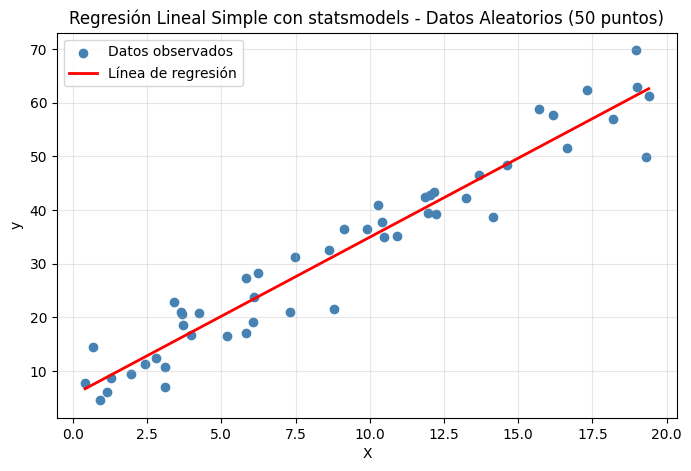

In [67]:
# Visualización de los datos, la recta ajustada y la banda de confianza
y_pred_p3 = modelo_p3.predict(X_p3_sm)

orden = np.argsort(X_p3.ravel())

plt.figure(figsize=(8, 5))
plt.scatter(X_p3, y_p3, color='steelblue', label='Datos observados')
plt.plot(X_p3.ravel()[orden], np.asarray(y_pred_p3).ravel()[orden], color='red', linewidth=2, label='Línea de regresión')
plt.title('Regresión Lineal Simple con statsmodels - Datos Aleatorios (50 puntos)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Punto 4: Predicción en un Conjunto de Datos Real

En este punto vamos a:
1. Utilizar el conjunto de datos `tips` de la biblioteca `seaborn`.
2. Realizar una regresión lineal simple para predecir la propina en función del total de la factura.
3. Hacer una predicción de la propina para una factura de $50.

In [68]:
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression

### 4.1 Carga del conjunto de datos `tips`

In [69]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 4.2 Regresión lineal simple: total de la factura vs. propina

In [70]:
# Variable independiente: total de la factura
X_tips = tips[['total_bill']]
# Variable dependiente: propina
y_tips = tips['tip']

# Crear y entrenar el modelo
modelo_p4 = LinearRegression()
modelo_p4.fit(X_tips, y_tips)

intercepto_p4 = modelo_p4.intercept_
pendiente_p4 = modelo_p4.coef_[0]

print(f"Intercepto: {intercepto_p4:.4f}")
print(f"Pendiente: {pendiente_p4:.4f}")
print(f"Ecuación ajustada: tip = {intercepto_p4:.4f} + {pendiente_p4:.4f} * total_bill")

Intercepto: 0.9203
Pendiente: 0.1050
Ecuación ajustada: tip = 0.9203 + 0.1050 * total_bill


### 4.3 Visualización de los datos y la línea de regresión

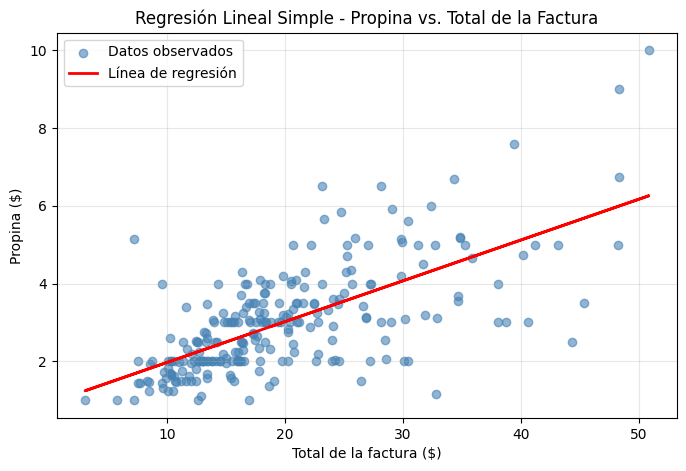

In [71]:
y_pred_tips = modelo_p4.predict(X_tips)

plt.figure(figsize=(8, 5))
plt.scatter(X_tips, y_tips, color='steelblue', alpha=0.6, label='Datos observados')
plt.plot(X_tips, y_pred_tips, color='red', linewidth=2, label='Línea de regresión')
plt.title('Regresión Lineal Simple - Propina vs. Total de la Factura')
plt.xlabel('Total de la factura ($)')
plt.ylabel('Propina ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 4.4 Predicción para una factura de $50

In [72]:
factura_nueva = pd.DataFrame({'total_bill': [50]})
propina_predicha = modelo_p4.predict(factura_nueva)[0]

print(f"Para una factura de $50.00, la propina predicha es de ${propina_predicha:.2f}")

Para una factura de $50.00, la propina predicha es de $6.17


## Punto 5: Comparación de Modelos

En este punto vamos a:
1. Utilizar el conjunto de datos `wine` de `sklearn.datasets`.
2. Realizar una regresión lineal simple con `scikit-learn` para predecir `alcohol` en función de otro atributo.
3. Realizar otra regresión lineal simple, esta vez con `statsmodels`.
4. Comparar los parámetros (intercepto y pendiente) obtenidos por ambos métodos.

In [73]:
from sklearn.datasets import load_wine
import statsmodels.api as sm

### 5.1 Carga del conjunto de datos `wine`

Se utilizará `color_intensity` (intensidad del color) como variable independiente para predecir `alcohol`.

In [74]:
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [75]:
# Variable independiente y dependiente
X_wine = df_wine[['color_intensity']]
y_wine = df_wine['alcohol']

### 5.2 Regresión lineal con scikit-learn

In [76]:
modelo_p5_sklearn = LinearRegression()
modelo_p5_sklearn.fit(X_wine, y_wine)

intercepto_sklearn = modelo_p5_sklearn.intercept_
pendiente_sklearn = modelo_p5_sklearn.coef_[0]

print(f"[scikit-learn] Intercepto: {intercepto_sklearn:.4f}")
print(f"[scikit-learn] Pendiente:  {pendiente_sklearn:.4f}")

[scikit-learn] Intercepto: 12.0329
[scikit-learn] Pendiente:  0.1913


### 5.3 Regresión lineal con statsmodels

In [77]:
X_wine_sm = sm.add_constant(X_wine)
modelo_p5_sm = sm.OLS(y_wine, X_wine_sm).fit()

intercepto_sm = modelo_p5_sm.params['const']
pendiente_sm = modelo_p5_sm.params['color_intensity']

print(f"[statsmodels] Intercepto: {intercepto_sm:.4f}")
print(f"[statsmodels] Pendiente:  {pendiente_sm:.4f}")

modelo_p5_sm.summary()

[statsmodels] Intercepto: 12.0329
[statsmodels] Pendiente:  0.1913


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                alcohol   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     74.90
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           3.06e-15
Time:                        03:37:32   Log-Likelihood:                -183.41
No. Observations:                 178   AIC:                             370.8
Df Residuals:                     176   BIC:                             377.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              12.0329      0.123     97.868      0.000      11.790      12.276
color_intensity     0.1913      0.022      8.654      0.000       0.148       0.235
==============================================================================
Omnibus:                        2.882   Durbin-Watson:                   1.009
Prob(Omnibus):                  0.237   Jarque-Bera (JB):                2.136
Skew:                           0.099   Prob(JB):                        0.344
Kurtosis:                       2.501   Cond. No.                         13.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 5.4 Comparación de parámetros

In [78]:
comparacion = pd.DataFrame({
    'Método': ['scikit-learn', 'statsmodels'],
    'Intercepto': [intercepto_sklearn, intercepto_sm],
    'Pendiente': [pendiente_sklearn, pendiente_sm]
})

comparacion

,Método,Intercepto,Pendiente
0,scikit-learn,12.032864,0.191328
1,statsmodels,12.032864,0.191328


**Interpretación:** Como se esperaba, scikit-learn y statsmodels dan exactamente los mismos valores de intercepto y pendiente, porque los dos usan mínimos cuadrados ordinarios por debajo. La diferencia no está en el resultado sino en para qué sirve cada librería: con scikit-learn uno arma el modelo rápido y lo usa para predecir, mientras que con statsmodels además nos da el summary() completo con errores estándar, p-values e intervalos de confianza, que es lo que usamos en el punto 3.